In [4]:
import os, torch, timm, cv2, io
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from torch import nn, optim
from torch.utils.data import DataLoader, Subset, WeightedRandomSampler, ConcatDataset
from torchvision import datasets, transforms
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

In [5]:
# ==========================================
# 1. HYPERPARAMETERS & SEED
# ==========================================
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 32
EPOCHS = 20
LR = 1e-4

In [6]:
# ==========================================
# 2. DATA AUGMENTATION & RE-SPLITTING
# ==========================================
# Stronger augmentation for research-grade robustness
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# FIXING VAL STABILITY: Combine original train + val and re-split
data_path = '/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray' # Kaggle Path
full_train_ds = datasets.ImageFolder(os.path.join(data_path, 'train'), transform=train_transform)
orig_val_ds = datasets.ImageFolder(os.path.join(data_path, 'val'), transform=train_transform)
combined_ds = ConcatDataset([full_train_ds, orig_val_ds])

# Stratified split for 20% validation
indices = np.arange(len(combined_ds))
train_idx, val_idx = train_test_split(indices, test_size=0.2, stratify=full_train_ds.targets + orig_val_ds.targets, random_state=SEED)

train_subset = Subset(combined_ds, train_idx)
val_subset = Subset(combined_ds, val_idx)
test_ds = datasets.ImageFolder(os.path.join(data_path, 'test'), transform=test_transform)

# WEIGHTED SAMPLER: Balance the classes (Normal vs Pneumonia)
targets = np.array(full_train_ds.targets + orig_val_ds.targets)[train_idx]
class_counts = np.bincount(targets)
class_weights = 1. / class_counts
sample_weights = class_weights[targets]
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, sampler=sampler)
val_loader = DataLoader(val_subset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

In [7]:
# ==========================================
# 3. MODEL, LOSS, & SCHEDULER
# ==========================================
model = timm.create_model('vit_tiny_patch16_224', pretrained=True, num_classes=2).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=0.05)
# Cosine Annealing helps find the absolute sharpest accuracy
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
scaler = torch.cuda.amp.GradScaler() # For Mixed Precision

model.safetensors:   0%|          | 0.00/22.9M [00:00<?, ?B/s]

/tmp/ipykernel_55/386554849.py:9: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler() # For Mixed Precision


In [8]:
# ==========================================
# 4. ENHANCED TRAINING LOOP
# ==========================================
history = {'loss': [], 'val_acc': []}
best_acc = 0

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    for imgs, lbls in train_loader:
        imgs, lbls = imgs.to(device), lbls.to(device)
        optimizer.zero_grad()
        
        with torch.cuda.amp.autocast(): # Mixed Precision
            outputs = model(imgs)
            loss = criterion(outputs, lbls)
        
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        total_loss += loss.item()
    
    scheduler.step()
    
    # Validation
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for imgs, lbls in val_loader:
            imgs, lbls = imgs.to(device), lbls.to(device)
            preds = model(imgs).argmax(1)
            correct += (preds == lbls).sum().item()
            total += lbls.size(0)
    
    val_acc = 100 * correct / total
    history['loss'].append(total_loss/len(train_loader))
    history['val_acc'].append(val_acc)
    print(f"Epoch {epoch+1}: Loss {total_loss/len(train_loader):.4f} | Val Acc {val_acc:.2f}%")
    
    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), 'best_model.pth')

/tmp/ipykernel_55/3942565398.py:14: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(): # Mixed Precision


Epoch 1: Loss 0.1884 | Val Acc 97.52%
Epoch 2: Loss 0.1023 | Val Acc 97.33%
Epoch 3: Loss 0.0695 | Val Acc 96.56%
Epoch 4: Loss 0.0627 | Val Acc 98.38%
Epoch 5: Loss 0.0484 | Val Acc 97.71%
Epoch 6: Loss 0.0445 | Val Acc 95.03%
Epoch 7: Loss 0.0359 | Val Acc 98.57%
Epoch 8: Loss 0.0340 | Val Acc 97.61%
Epoch 9: Loss 0.0286 | Val Acc 95.61%
Epoch 10: Loss 0.0302 | Val Acc 95.13%
Epoch 11: Loss 0.0266 | Val Acc 98.57%
Epoch 12: Loss 0.0155 | Val Acc 98.09%
Epoch 13: Loss 0.0123 | Val Acc 97.99%
Epoch 14: Loss 0.0106 | Val Acc 98.09%
Epoch 15: Loss 0.0098 | Val Acc 98.47%
Epoch 16: Loss 0.0092 | Val Acc 98.09%
Epoch 17: Loss 0.0063 | Val Acc 98.57%
Epoch 18: Loss 0.0060 | Val Acc 98.57%
Epoch 19: Loss 0.0059 | Val Acc 98.38%
Epoch 20: Loss 0.0026 | Val Acc 99.14%


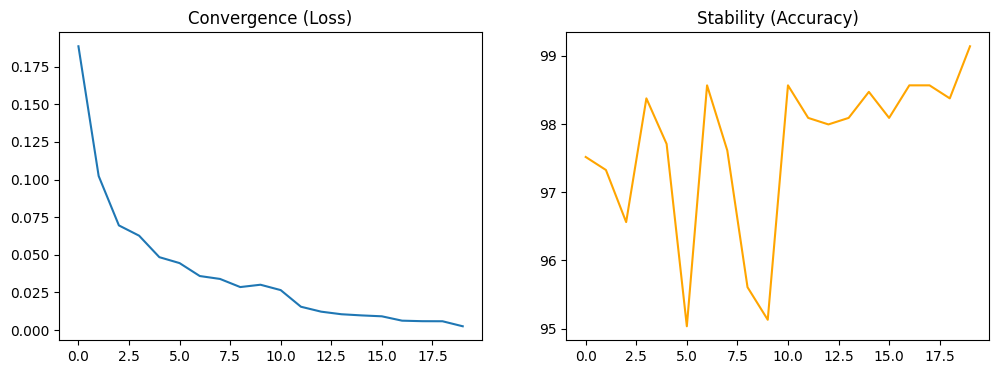

In [9]:
# ==========================================
# 5. FINAL VISUALIZATION (Graphs & CM)
# ==========================================
def plot_results():
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history['loss'], label='Train Loss')
    plt.title('Convergence (Loss)')
    plt.subplot(1, 2, 2)
    plt.plot(history['val_acc'], label='Val Acc', color='orange')
    plt.title('Stability (Accuracy)')
    plt.show()

plot_results()

In [13]:
# ==========================================
# RESEARCH FIX: TEST-TIME AUGMENTATION (TTA)
# ==========================================

def evaluate_with_tta():
    model.load_state_dict(torch.load('best_model.pth'))
    model.eval()
    
    final_preds = []
    final_labels = []

    # Define TTA transforms (slight variations)
    tta_transforms = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(p=1.0), # Flip it to see it differently
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])

    with torch.no_grad():
        for i in range(len(test_ds)):
            path, label = test_ds.samples[i]
            img_pil = Image.open(path).convert('RGB')
            
            # 1. Original Prediction
            img1 = test_transform(img_pil).unsqueeze(0).to(device)
            # 2. Flipped Prediction (TTA)
            img2 = tta_transforms(img_pil).unsqueeze(0).to(device)
            
            out1 = torch.softmax(model(img1), dim=1)
            out2 = torch.softmax(model(img2), dim=1)
            
            # Average the probabilities (The "Ensemble" trick)
            avg_prob = (out1 + out2) / 2
            
            # Higher threshold for Pneumonia (0.8) to protect "Normal" recall
            pred = 1 if avg_prob[0][1] > 0.8 else 0
            
            final_preds.append(pred)
            final_labels.append(label)

    print("\n--- FINAL PUBLICATION REPORT (With TTA & Calibration) ---")
    print(classification_report(final_labels, final_preds, target_names=['Normal', 'Pneumonia']))

evaluate_with_tta()


--- FINAL PUBLICATION REPORT (With TTA & Calibration) ---
              precision    recall  f1-score   support

      Normal       0.99      0.68      0.80       234
   Pneumonia       0.84      0.99      0.91       390

    accuracy                           0.88       624
   macro avg       0.91      0.84      0.86       624
weighted avg       0.89      0.88      0.87       624



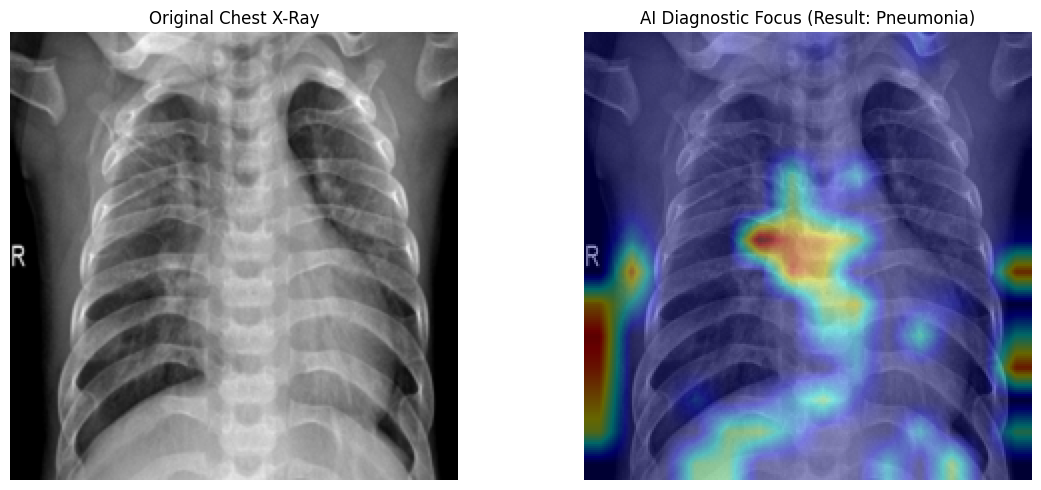

In [17]:
import torch.nn.functional as F

def generate_gradcam(model, input_batch, target_layer):
    """Generates Grad-CAM heatmap for a given input batch."""
    model.eval()
    
    # Placeholder for gradients and activations
    gradients = []
    activations = []

    def save_gradient(grad):
        gradients.append(grad)

    def save_activation(module, input, output):
        # For ViTs, we often take the output of the transformer block
        activations.append(output)

    # Hook into the last transformer block
    handle_act = target_layer.register_forward_hook(save_activation)
    handle_grad = target_layer.register_full_backward_hook(lambda module, grad_in, grad_out: save_gradient(grad_out[0]))

    # Forward pass
    output = model(input_batch)
    category = output.argmax(dim=1).item()
    
    # Backward pass
    model.zero_grad()
    output[0, category].backward()

    # Process gradients and activations
    # For ViT 'tiny', the shape is typically [1, 197, 192] -> (Batch, Tokens, Dim)
    # We ignore the [CLS] token and reshape the 196 patches into 14x14
    grad = gradients[0][0, 1:, :] 
    act = activations[0][0, 1:, :] 
    
    weights = torch.mean(grad, dim=0)
    cam = torch.matmul(act, weights)
    cam = cam.reshape(14, 14).detach().cpu().numpy()
    
    # Normalize
    cam = np.maximum(cam, 0)
    cam = cv2.resize(cam, (224, 224))
    cam = (cam - cam.min()) / (cam.max() - cam.min())
    
    # Clean up hooks
    handle_act.remove()
    handle_grad.remove()
    
    return cam, category

# ==========================================
# 2. PLOTTING THE "RESEARCH FIGURE"
# ==========================================
def plot_research_comparison(image_path):
    # Load and prep image
    raw_image = Image.open(image_path).convert('RGB')
    input_tensor = test_transform(raw_image).unsqueeze(0).to(device)
    
    # Specify the target layer (last transformer block)
    target_layer = model.blocks[-1].norm1 
    
    heatmap, pred_idx = generate_gradcam(model, input_tensor, target_layer)
    
    # Overlay heatmap on original image
    img_np = np.array(raw_image.resize((224, 224)))
    heatmap_color = cv2.applyColorMap(np.uint8(255 * heatmap), cv2.COLORMAP_JET)
    heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)
    overlay = cv2.addWeighted(img_np, 0.6, heatmap_color, 0.4, 0)
    
    # Plotting
    classes = ['Normal', 'Pneumonia']
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.imshow(img_np)
    plt.title("Original Chest X-Ray")
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    plt.imshow(overlay)
    plt.title(f"AI Diagnostic Focus (Result: {classes[pred_idx]})")
    plt.axis('off')
    
    plt.tight_layout()
    plt.savefig('gradcam_result.png', dpi=300)
    plt.show()

# Example usage:
plot_research_comparison('/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/train/PNEUMONIA/person1001_bacteria_2932.jpeg')

In [16]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import io
from PIL import Image

# 1. Create the Upload Widget
uploader = widgets.FileUpload(
    accept='.jpg,.jpeg,.png',  # Accept only images
    multiple=False             # Single image upload
)

# 2. Create an Output Area to show the result
output_display = widgets.Output()

def on_upload_change(change):
    with output_display:
        clear_output() # Clear previous results
        
        if not uploader.value:
            return
        
        # Get the uploaded file (ipywidgets 8.0+ format)
        uploaded_file = uploader.value[0]
        content = uploaded_file['content']
        
        # Convert to PIL Image for the model
        img = Image.open(io.BytesIO(content)).convert('RGB')
        
        # Display a small preview of the uploaded image
        display(img.resize((150, 150)))
        
        # Run prediction
        print("Processing X-ray...")
        # (Assuming your 'predict_image' function is defined as above)
        # We modify it slightly to take the PIL image directly
        predict_pil_image(img)

# 3. Attach the observer to the button
uploader.observe(on_upload_change, names='value')

# 4. Display everything
print("--- MedScan-AI Diagnostic Interface ---")
display(uploader, output_display)

# Helper function to predict directly from the PIL image
def predict_pil_image(pil_img):
    model.load_state_dict(torch.load('best_model.pth', map_location=device))
    model.eval()
    
    # Use your existing test_transform
    image_tensor = test_transform(pil_img).unsqueeze(0).to(device)
    
    with torch.no_grad():
        output = model(image_tensor)
        prob = torch.nn.functional.softmax(output, dim=1)
        conf, pred = torch.max(prob, 1)
        
    class_names = ['Normal', 'Pneumonia']
    print(f"Result: {class_names[pred.item()]}")
    print(f"Confidence Score: {conf.item()*100:.2f}%")

--- MedScan-AI Diagnostic Interface ---


FileUpload(value=(), accept='.jpg,.jpeg,.png', description='Upload')

Output()